# 実行例6.3 アヤメデータの判別空間の校正（p.88図6.8）

### 0. 多クラスにおけるフィッシャーの基準による線形識別
- 大方針 : クラス間分散 $S_B$ とクラス内分散 $S_W$ の比を最大化する。
- 考え方
1. クラス間分散とクラス内分散を取る。
    - クラス間分散 $S_B$ : クラス同士が離れているほど良い（大きいほど良い）。
    - クラス内分散 $S_W$ : クラス内部が固まっているほど良い（小さいほど良い）。
2. フィッシャーの基準
    - フィッシャーの基準 $S_B/S_W$ : $S_B$ が大きく $S_W$ が小さい方向（軸）を見つけたい。
    - ただし3クラス以上だと行列同士の比となりスカラー量に変換する必要がある。
    - 逆行列 $S_W^{-1}$ を取って $S_W^{-1}S_B$ という行列を作る。
    - $S_W^{-1}S_B$ のトレース（$Tr$ : 対角成分の合計）操作を行いスカラー量にする。
    $$
    J(W) = Tr(S_W^{-1}S_B) = Tr((W^T S_W W)^{-1} W^T S_B W)
    $$
3. $S_W^{-1}S_B$ を固有値分解する。
    - 固有値の大きさ ＝ その方向（軸）が「クラスをどれだけうまく分けているか」のスコア
    - 固有ベクトル ＝ その方向（軸）そのもの
4. 固有ベクトルで判別する。
    - 固有値が最大の固有ベクトルを第1軸（LD1）とする。
    - （3クラスなら）固有値が2番目の固有ベクトルを第2軸（LD2）とする。

- パッケージのインポートと関数類は`4.1_2_iris-standardization_plot.ipynb`他を流用

In [26]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 対象データの準備

#### 1.1 アヤメデータの読み込み
- X（花弁の長さと幅、萼の長さと幅の4種類のデータの行列）の作成に関して
    - 行列にする理由 : ループで扱いやすい。
    - `Vector{Vector{Float64}}` を経由する理由 : 行列は事前にサイズが決まっていないと宣言できない。
        - これはできない（Nがまだわからない）
        ```
        X = Matrix{Float64}(undef, N, 4)  # Nを知っていれば可能
        ```
        - Nが既知なら最初から行列で直接埋めるほうが効率的（今回は150とわかっているのでこちらを使う手もある）
         ```
        X = Matrix{Float64}(undef, 150, 4)

        for (i, line) in enumerate(lines)
            _, sl, sw, pl, pw, sp = split(line, ",")
            X[i, 1] = parse(Float64, sl)
            X[i, 2] = parse(Float64, sw)
            X[i, 3] = parse(Float64, pl)
            X[i, 4] = parse(Float64, pw)
            push!(Species, strip(sp))
        end
        ```
        - `X = hcat(sepal_length, sepal_width, petal_length, petal_width)  `や`reduce(hcat, X)'` はNが不明なときの回避策

In [27]:
# (1)iris.csvのファイルパスを設定する
filepath = "iris.csv"

# (2)iris.csvを読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)学習データ数の確認
N = length(lines)

# (4)データ配列の準備
sepal_length = Float64[]
sepal_width = Float64[]
petal_length = Float64[]
petal_width = Float64[]
Species = String[]

# X = Vector{Float64}[]    # 花弁と萼を含むベクトル(要素数不明でもOK、中にVector{Float64}があってもOK)

# (5)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, sepal_length_x, sepal_width_x, petal_length_x, petal_width_x, species_x = split(line, ",")
    push!(sepal_length, parse(Float64, sepal_length_x))
    push!(sepal_width, parse(Float64, sepal_width_x))
    push!(petal_length, parse(Float64, petal_length_x))
    push!(petal_width, parse(Float64, petal_width_x))
    push!(Species, strip(species_x))

    # push!(X, [
    # parse(Float64, sepal_length_x),
    # parse(Float64, sepal_width_x),
    # parse(Float64, petal_length_x),
    # parse(Float64, petal_width_x)
    # ])   # 花弁と萼を含むベクトルのリスト（Vector{Vector{Float64}}）
end

# (6)行列 + ラベルベクトル
X = hcat(sepal_length, sepal_width, petal_length, petal_width)  # N×4行列,Matrix{Float64},(150, 4)
y = Species # N要素のVector{String}
# もしくは花弁と萼を含むベクトルのリストから
# X = reduce(hcat, X)'  # Adjoint{Float64, Matrix{Float64}}   
#or
# X = vcat(X'...)  # Matrix{Float64}
@show(typeof(X), size(X))

typeof(X) = Matrix{Float64}
size(X) = (150, 4)


(150, 4)

#### 1.2 クラス分けしたデータ準備
- クラス略称
    - sts : "setosa"
    - vsc : "versicolor"
    - vgn : "virginica"
- Juliaは`Matrix`に対してもリニアインデックス（左上から列優先で取ってくる）が使える。逆に意図した行・列を取りたい時は2つのインデックスを使ったほうが明確
```julia
X[1]    # = X[1,1]
X[2]    # = X[2,1]  ← 2行目、1列目（列優先なので）
X[151]  # = X[1,2]  ← 1行目、2列目
```
- `XC[i] = data_xxx`は既存の要素を上書きする操作なので、先に要素がないとBoundsErrorになる。`push!(XC, data_xxx)`で追加していく。ただし`XC = [data_sts, data_vsc, data_vgn]`の方が楽でスマート。

In [28]:
# (1)データサイズ
nrow, ncol = size(X)

# (2)クラスごとのデータ配列準備
# 配列形式のデータセットの準備
XC = Vector{Vector{Vector{Float64}}}()
# sts(setosa)
data_sts = [X[i, : ] for i in 1:nrow if y[i] == "setosa"]
# vsc(versicolor)
data_vsc = [X[i, : ] for i in 1:nrow if y[i] == "versicolor"]
# vgn(virginica)
data_vgn = [X[i, : ] for i in 1:nrow if y[i] == "virginica"]
# 配列形式のデータセットに要素を追加
# push!(XC, data_sts)
# push!(XC, data_vsc)
# push!(XC, data_vgn)
XC = [data_sts, data_vsc, data_vgn]   # XC[1] : data_sts, XC[2] : data_sc, XC[3] : data_vgn

3-element Vector{Vector{Vector{Float64}}}:
 [[5.1, 3.5, 1.4, 0.2], [4.9, 3.0, 1.4, 0.2], [4.7, 3.2, 1.3, 0.2], [4.6, 3.1, 1.5, 0.2], [5.0, 3.6, 1.4, 0.2], [5.4, 3.9, 1.7, 0.4], [4.6, 3.4, 1.4, 0.3], [5.0, 3.4, 1.5, 0.2], [4.4, 2.9, 1.4, 0.2], [4.9, 3.1, 1.5, 0.1]  …  [5.0, 3.5, 1.3, 0.3], [4.5, 2.3, 1.3, 0.3], [4.4, 3.2, 1.3, 0.2], [5.0, 3.5, 1.6, 0.6], [5.1, 3.8, 1.9, 0.4], [4.8, 3.0, 1.4, 0.3], [5.1, 3.8, 1.6, 0.2], [4.6, 3.2, 1.4, 0.2], [5.3, 3.7, 1.5, 0.2], [5.0, 3.3, 1.4, 0.2]]
 [[7.0, 3.2, 4.7, 1.4], [6.4, 3.2, 4.5, 1.5], [6.9, 3.1, 4.9, 1.5], [5.5, 2.3, 4.0, 1.3], [6.5, 2.8, 4.6, 1.5], [5.7, 2.8, 4.5, 1.3], [6.3, 3.3, 4.7, 1.6], [4.9, 2.4, 3.3, 1.0], [6.6, 2.9, 4.6, 1.3], [5.2, 2.7, 3.9, 1.4]  …  [5.5, 2.6, 4.4, 1.2], [6.1, 3.0, 4.6, 1.4], [5.8, 2.6, 4.0, 1.2], [5.0, 2.3, 3.3, 1.0], [5.6, 2.7, 4.2, 1.3], [5.7, 3.0, 4.2, 1.2], [5.7, 2.9, 4.2, 1.3], [6.2, 2.9, 4.3, 1.3], [5.1, 2.5, 3.0, 1.1], [5.7, 2.8, 4.1, 1.3]]
 [[6.3, 3.3, 6.0, 2.5], [5.8, 2.7, 5.1, 1.9], [7.1, 3.0, 5.9, 2.1],

### 2. フィッシャーの基準によるクラス判別

#### 2.1 フィッシャーの基準の計算関数
- `reduce(hcat, x)'`のやっていること
    - x(x_1~3)は`Vector{Vector{Float64}}`
        x_1 = [[5.1, 3.5, 1.4, 0.2],
        [4.9, 3.0, 1.4, 0.2],
        ...]   # 50個
    - `reduce(hcat, x)`から`reduce`で`x`（列ベクトル）を順に取り出して`hcat`で横に並べていく（`reduce`関数 : 配列やイテレータの要素を先頭から順に二項演算子または関数に適用し、スカラーなどの単一の集約値を計算するための高階関数）、スプラット関数`hcat(x...)`でも同等だが要素数が多いとパフォーマンスが落ちることがある。
        4×50 の Matrix{Float64}
        [5.1  4.9  ...
        3.5  3.0  ...
        1.4  1.4  ...
        0.2  0.2  ...]
    - `'`（転置）で50×4にする：
        50×4 の Matrix{Float64}
        [5.1  3.5  1.4  0.2
        4.9  3.0  1.4  0.2
        ...]
    - `cov`は行がサンプル、列が特徴量」の形式を期待するので転置が必要

##### 2.1.1 K=3クラス専用

In [29]:
# (1)クラス間分散
function between_class_var(x_1, x_2, x_3)
    # データ数
    N_1 = length(x_1)
    N_2 = length(x_2)
    N_3 = length(x_3)
    N = N_1 + N_2 + N_3
    # 事前確率
    P_1 = N_1 / N
    P_2 = N_2 / N
    P_3 = N_3 / N
    # 平均ベクトル
    m_1 = mean(x_1)
    m_2 = mean(x_2)
    m_3 = mean(x_3)
    m_bar = mean([x_1; x_2; x_3])
    # クラス間分散
    σ_B2 = P_1 * (m_1 - m_bar) * (m_1 - m_bar)' 
         + P_2 * (m_2 - m_bar) * (m_2 - m_bar)' 
         + P_3 * (m_3 - m_bar) * (m_3 - m_bar)'
    return σ_B2
end

# (2)クラス内分散
function within_class_var(x_1, x_2, x_3)
    # データ数
    N_1 = length(x_1)
    N_2 = length(x_2)
    N_3 = length(x_3)
    N = N_1 + N_2 + N_3
    # 事前確率
    P_1 = N_1 / N
    P_2 = N_2 / N
    P_3 = N_3 / N
    # クラスごとの共分散
    Σ_1 = cov(reduce(hcat, x_1)')
    Σ_2 = cov(reduce(hcat, x_2)')
    Σ_3 = cov(reduce(hcat, x_3)')
    # クラス内分散
    σ_W2 = P_1 * Σ_1 + P_2 * Σ_2 + P_3 * Σ_3
    return σ_W2
end

within_class_var (generic function with 2 methods)

##### 2.1.2 多クラス汎用
- `sum(length.(XC))` : 全クラスのデータ数合計 → 150
- `length.(XC)` : クラスごとの数も見たい場合 → [50, 50, 50]
- `length(XC[1][1])` : 個別のデータの次元数 → 4, `length(first(first(XC)))`と書けなくもないが`[1][1]`で指定した方が可読性が高い。
- [x for x in 1:N]のような内包表記は「各要素を変換してリストを作る」ものなので、累積（インクリメント）には向かない。
```julia
# インクリメントしない
s = zeros(d, d)
σ_B2 = [s .+ (PC[i] * (mc[i] - m_bar) * (mc[i] - m_bar)') for i in 1:K]
σ_W2 = [s .+ (PC[i] * Σ[i]) for i in 1:K]
# sumを使う
σ_B2 = sum(PC[i] * (mc[i] - m_bar) * (mc[i] - m_bar)' for i in 1:K)
σ_W2 = sum(PC[i] * Σ[i] for i in 1:K)
```


In [30]:
# (1)共通統計値の算出
function stats_data(XC)
    # クラス数
    K = length(XC)
    # 次元数
    d = length(XC[1][1])    # length(first(first(XC)))と書けなくもない。
    # 各クラスのデータ数
    NC = length.(XC)
    # データ総数
    N = sum(NC)
    # 事前確率
    PC = NC ./ N
    # 平均ベクトル
    mc = mean.(XC)
    m_bar = mean(mc)

    return K, d, NC, N, PC, mc, m_bar
end

# (2)クラス間分散
function between_class_var(XC)   
    K, d, NC, N, PC, mc, m_bar = stats_data(XC)
    
    # クラス間分散
    σ_B2 = sum(PC[i] * (mc[i] - m_bar) * (mc[i] - m_bar)' for i in 1:K)

    return σ_B2
end

# (3)クラス内分散
function within_class_var(XC)
    K, d, NC, N, PC, mc, m_bar = stats_data(XC)
    
    # クラスごとの共分散行列
    Σ = [cov(reduce(hcat, XC[i])') for i in 1:K]
    
    # クラス内分散
    σ_W2 = sum(PC[i] * Σ[i] for i in 1:K)

    return σ_W2
end

within_class_var (generic function with 2 methods)

##### 2.1.3 具体的なクラス間分散、クラス内分散の計算

In [31]:
# (1)クラス間分散、クラス内分散の計算
S_B = between_class_var(XC)
S_W = within_class_var(XC)
@show(S_B, S_W)

S_B = [0.4214142222222217 -0.13301777777777807 1.1016559999999993 0.47519555555555526; -0.13301777777777807 0.07563288888888903 -0.38159733333333395 -0.15288444444444477; 1.1016559999999993 -0.38159733333333395 2.9140186666666654 1.2451599999999998; 0.47519555555555526 -0.15288444444444477 1.2451599999999998 0.5360888888888888]
S_W = [0.2650081632653061 0.09272108843537412 0.16751428571428573 0.03840136054421769; 0.09272108843537412 0.11538775510204081 0.05524353741496598 0.03271020408163265; 0.16751428571428573 0.05524353741496598 0.18518775510204089 0.04266530612244897; 0.03840136054421769 0.03271020408163265 0.04266530612244897 0.04188163265306122]


4×4 Matrix{Float64}:
 0.265008   0.0927211  0.167514   0.0384014
 0.0927211  0.115388   0.0552435  0.0327102
 0.167514   0.0552435  0.185188   0.0426653
 0.0384014  0.0327102  0.0426653  0.0418816

#### 2.2 フィッシャーの線形判別

##### 2.2.1 (a)2次元判別空間への写像分布と線形識別境界
- 方針
    1.  4次元から2次元の写像 ＝ フィッシャーの基準（幾何学的アプローチ） … 次元削減（写像）の段階では、「クラス間分散を大きく、クラス内分散を小さくする（比を最大化する）」 というフィッシャーの基準（ $J(W)$ の最大化）を純粋に使用。これは確率分布を仮定しない、幾何学的なアプローチ。
    2. 線形識別境界を引く ＝ ベイズ誤り率最小識別規則（確率的アプローチ） … 本に「正規分布を仮定した線形識別関数」と書かれている通り、ベイズの定理に基づく誤り率最小化（正則判別分析） を用いて線形識別境界を引く。これは「4.2.2 正規分布から導かれる識別関数」（4.4_pima-recognition.ipynb）の手順に従う。
- 手順
    1. 4次元空間全体で計算 … 4つの特徴量（がく片の長さ・幅、花弁の長さ・幅）の組み合わせを含めた「4×4の共分散行列」を計算する。これにより、「どの特徴量とどの特徴量の組み合わせがクラスを分けるのに役立つか」を全体像から捉える。
    2. 最適な軸（判別軸）を見つける … 4次元空間の中で「クラス間分散が大きく、クラス内分散が小さい」方向（軸）を数学的に探し出す。アヤメデータは3クラスなので、最大で2本の重要な軸（判別軸）が見つかる（クラス数 - 1 = 2）。
    3. 2次元に投影（写像） …　見つかった2本の軸を使って、4次元のデータを2次元のグラフ（図a）に落とし込む。
        1. 固有値を求める … $S_W^{-1}S_B$ を固有値分解すると4次元空間なので4つの固有ベクトル（候補）とそれに対応した4つの固有値が得られる。この固有値が「その軸がどれだけクラスをうまく分けるか」というスコアになっている。このスコアが大きい順に上位2つ（第1軸、第2軸）だけを選ぶ。
        2. 4次元のデータを2次元に写像する
            - 選ばれた2つの固有ベクトルを $w_1, w_2$ とする。
            - 選んだ固有ベクトルを横に並べて、変換行列 $W$ （4行2列）を作成する。
            ```julia
            W = [w_1 w_2]   # もしくはW = hcat(w_1, w_2)
            ```
            - 元の4次元データ $x$ （4行1列のベクトル）に $W$ を掛けて写像（投影）の実行する。
            $$
            x_{new} = W^T x
            $$
            - この計算を全データ（150個）に対して行い、すべてのデータ点が「$(LD1の座標、LD2の座標)$という2次元座標値に変換する。
    4. 線を描画する。
        - 4次元空間で計算された「クラスとクラスの境界面の方程式」を、2次元空間（LD1, LD2空間）での直線の方程式に引き直す。
        - そして、プロットしたデータ点の間に、クラスAとクラスBを分ける直線、クラスBとクラスCを分ける直線…というふうに「識別境界線」を引く。
- 固有値、固有ベクトルの計算
    - `eigen` : `LinearAlgebra` パッケージに入っている。
    - 基本的な使い方
    ```julia
    using LinearAlgebra
    result = eigen(A)
    # 固有値
    result.values        # 配列で返ってくる
    # 固有ベクトル（列ごとに格納されている）
    result.vectors
    ```
    - 固有ベクトルは「列」に格納され横に並んでいる
        - `result.vectors[:, 1]` が第1固有値に対応する固有ベクトル
        - なので `[w_1 w_2]` ではなく、スライスで直接取り出る。
    -  固有値は実数とは限らない
        - `S_W^{-1} S_B` は対称行列ではないので、複素数になることがある。
        - 実際には実数になるはずなので、`real()` をかませると安心
        ```julia
        eigenvalues = real(result.values)
        eigenvectors = real(result.vectors)
        ```
    - **数値的に安定させるには**
        - `inv(S_W) * S_B` を直接計算するより、**一般化固有値問題**として解く方が安定する。
        ```julia
        # S_W^{-1} S_B の固有値問題 = 一般化固有値問題
        result = eigen(S_B, S_W)
        ```
    - 数学的な違い
		1. 方法A（`inv(S_W) * S_B`）:
		$$ S_W^{-1} S_B w = \lambda w $$
			まず $S_W$ の逆行列 $S_W^{-1}$ を明示的に計算し、それを $S_B$ に掛けてから固有値分解
		2. 方法B（`eigen(S_B, S_W)`）:
		$$ S_B w = \lambda S_W w $$
			これは**一般化固有値問題**と呼ばれる。逆行列 $S_W^{-1}$ を作らずに、この方程式を直接満たす $\lambda$ と $w$ を探す。
	- なぜ方法B（一般化固有値問題）が「安定」なのか？
		最大の理由は、「**逆行列計算という、誤差が生まれやすい工程をスキップできるから**」
		- 計算誤差（丸め誤差）が減る
		- 「逆行列がない」状態でも計算できる

STEP.1 4次元空間からフィッシャーの基準を用いた2次元空間への写像

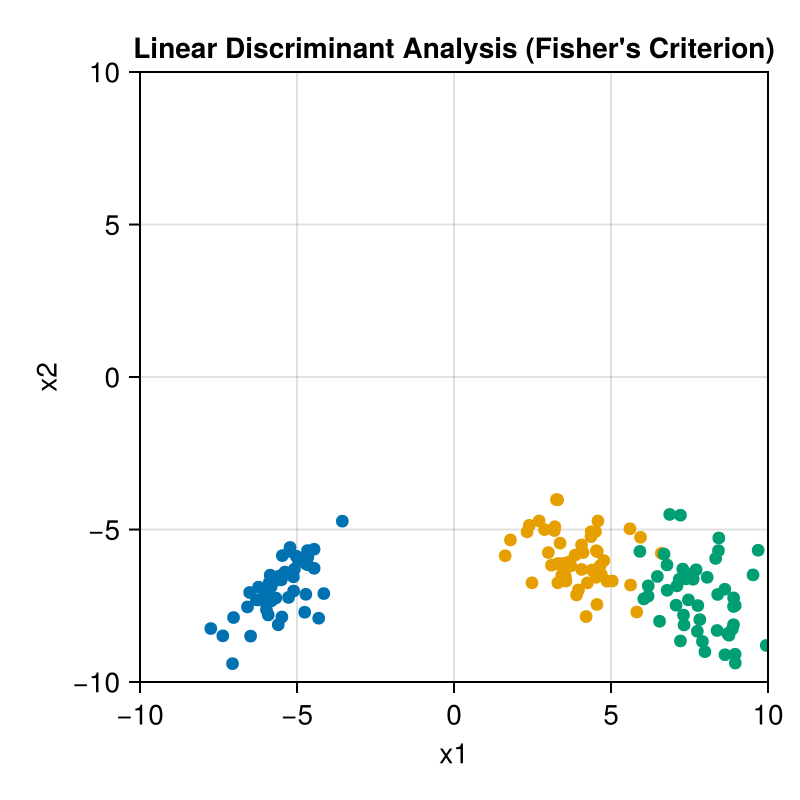

In [ ]:
# (１)固有値を求める
# 手順通りに行う場合
# A = inv(S_W) * S_B
# result = eigen(A)
# S_W^{-1} S_B の固有値問題 = 一般化固有値問題として解く場合（こちらの方が安定）
result = eigen(S_B, S_W)

# (2)固有値の大きい順に並び替える
idx = sortperm(result.values, rev=true)

# (3)上位2つの固有ベクトルを取り出してWを作る
W = result.vectors[:, idx[1:2]] # スライスで取り出せる

# (4)固有ベクトル空間に写像する
x_new_sts = [W' * x for x in data_sts]
x_new_vsc = [W' * x for x in data_vsc]
x_new_vgn = [W' * x for x in data_vgn]

# (5)データのプロット
fig =Figure(size=(400,400))
ax = Axis(fig[1, 1],
    title="Linear Discriminant Analysis (Fisher's Criterion)",
    xlabel="x1",
    ylabel="x2",
    xticks=-10.0:5.0:10.0,
    yticks=-10.0:5.0:10.0,
    limits=((-10.0, 10.0), (-10.0, 10.0))
)

scatter!(ax, Point2f.(x_new_sts))
scatter!(ax, Point2f.(x_new_vsc))
scatter!(ax, Point2f.(x_new_vgn))

fig



STEP.2 ベイズ識別による線形識別境界の描画
- 2次曲面の識別境界（p.48 式4.32）
$$
\begin{split}
f_{ij}(x) &= g_i(x) - g_j(x) \\
&= (x - \mu_i)^T \Sigma_i^{-1} (x - \mu_i) + \ln|\Sigma_i| - 2\ln P(C_i) \\
&\quad - (x - \mu_j)^T \Sigma_j^{-1} (x - \mu_j) - \ln|\Sigma_j| + 2\ln P(C_j) \\
&= \underbrace{x^T (\Sigma_i^{-1} - \Sigma_j^{-1}) x}_{\text{行列}S} 
+ \underbrace{2(\mu_j^T \Sigma_j^{-1} - \mu_i^T \Sigma_i^{-1}) x
}_{\text{ベクトル}c^T} \\
&\quad + \underbrace{\mu_i^T \Sigma_i^{-1} \mu_i - \mu_j^T \Sigma_j^{-1} \mu_j + \ln (\frac{|\Sigma_i|}{|\Sigma_j|}) - 2\ln (\frac{P(C_i)}{P(C_j)})}_{\text{スカラー}F} \\
&= x^T S x + 2 c^T x + F = 0
\end{split}
$$
- 線形識別境界（p.50 式4.37） …　2つのクラスの共分散行列が等しいものとするため共通の共分散行列を下記で求めている。
$$
\Sigma_{pool} = \frac{N_1}{N} \Sigma_1 + \frac{N_2}{N} \Sigma_2 = \frac{1}{N} (S_1 + S_2)
$$
- 4次元空間を2次元空間（LD1, LD2）に写像するために、平均と共分散も投影空間に変換
$$
\text{平均 : } \mu_{proj} = W^T \mu_K \\
\text{共分散 : } \Sigma_{proj} = W^T \Sigma_K W
$$

NG : 元データ（4次元）と写像データ（2次元）の扱いが混在して識別ができていない。

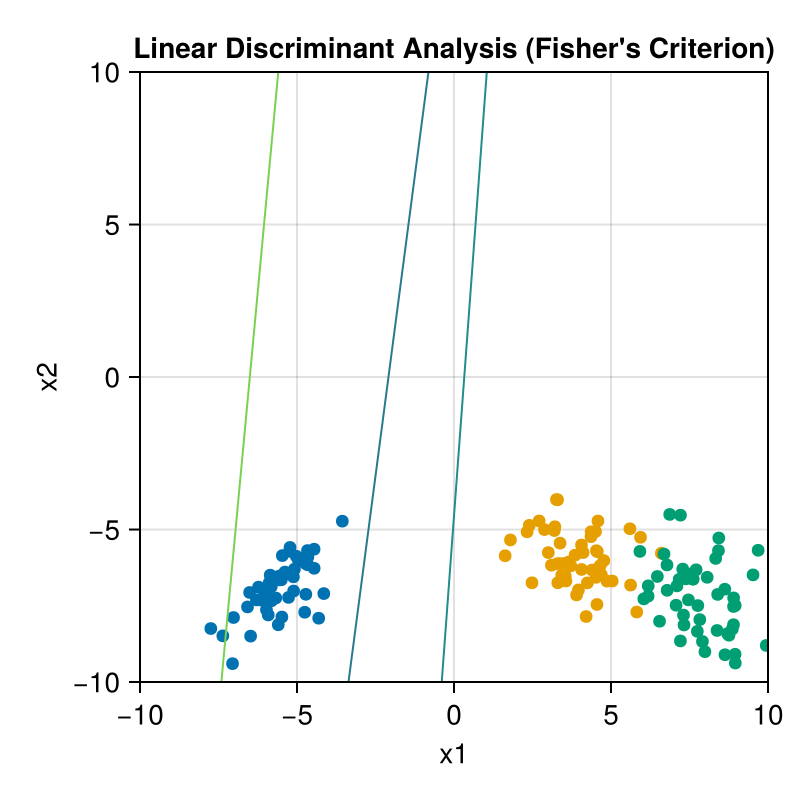

In [33]:
# (1)識別関数
function f_ij(x, XC, i, j, W, S_W)
    # 統計値の取得
    # K : クラス数, d : 特徴ベクトルの次元数, NC : クラスごとのデータ数, N : 全体のデータ数, PC : クラスごとの事前確率, mc : クラスごとの平均ベクトル, m_bar : 全体の平均ベクトル
    K, d, NC, N, PC, mc, m_bar = stats_data(XC)

    # クラスごとの共分散行列
    Σ = [cov(reduce(hcat, XC[i])') for i in 1:K]
    # 共通共分散行列
    Σ_pool = (NC[i] * Σ[i] + NC[j] * Σ[j]) / (NC[i] + NC[j])

    Σ[i] = Σ_pool
    Σ[j] = Σ_pool

    # 平均と共分散を投影空間に変換
    mc_proj = [W' * mc[k] for k in 1:K]
    Σ_proj = [W' * Σ[k] * W for k in 1:K]

    # 識別関数のパラメーター
    # 行列S
    S = inv(Σ_proj[i]) - inv(Σ_proj[j])
    # ベクトルc^T
    c_T = (transpose(mc_proj[i]) * inv(Σ_proj[i])) - (transpose(mc_proj[j]) * inv(Σ_proj[j]))
    # スカラーF
    F = (transpose(mc_proj[i]) * inv(Σ_proj[i]) * mc_proj[i]) - (transpose(mc_proj[j]) * inv(Σ_proj[j]) * mc_proj[j]) + (logdet(Σ_proj[i]) - logdet(Σ_proj[j])) - 2 * log(PC[i] / PC[j])

    # 識別関数
    f_dec = transpose(x) * S * x + 2 * c_T * x + F

    return f_dec[1]  # 行列演算の結果は1×1行列になるので[1]でスカラーとして返す
end

# (2)識別境界を描画するためのグリッドを作成
x_1 = range(-10.0, 10.0, length=100)
x_2 = range(-10.0, 10.0, length=100)

# (3)グリッド全体に対して識別境界関数f_ijを適用して高さの行列zを計算
z_12 = [f_ij([x1, x2], XC, 1, 2, W, S_W) for x1 in x_1, x2 in x_2]
z_23 = [f_ij([x1, x2], XC, 2, 3, W, S_W) for x1 in x_1, x2 in x_2]
z_31 = [f_ij([x1, x2], XC, 3, 1, W, S_W) for x1 in x_1, x2 in x_2]

# (3)データの再プロット
empty!(ax)
scatter!(ax, Point2f.(x_new_sts))
scatter!(ax, Point2f.(x_new_vsc))
scatter!(ax, Point2f.(x_new_vgn))

# (4)識別境界の描画
contour!(ax, x_1, x_2, z_12, levels=[0.0])
contour!(ax, x_1, x_2, z_23, levels=[0.0])
contour!(ax, x_1, x_2, z_31, levels=[0.0])

save("xoutput.png", fig)
fig

OK : 識別境界を2次元に写像したデータから計算することで識別ができている。

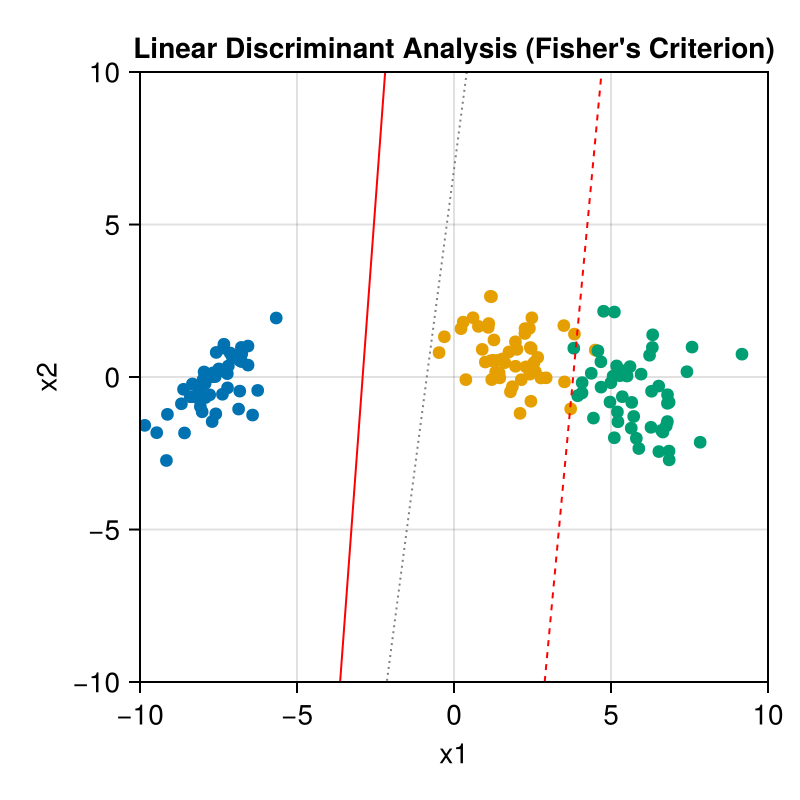

In [ ]:
# (1)2D写像済みデータで識別境界を計算
function boundary_2d(x_new_i, x_new_j)
    μ_i = mean(x_new_i)
    μ_j = mean(x_new_j)
    Σ_i = cov(reduce(hcat, x_new_i)')
    Σ_j = cov(reduce(hcat, x_new_j)')
    N_i, N_j = length(x_new_i), length(x_new_j)
    S_W = (N_i * Σ_i + N_j * Σ_j) / (N_i + N_j)
    
    w = inv(S_W) * (μ_i - μ_j)       # 2D判別方向
    t = dot(w, (μ_i + μ_j) / 2)      # 閾値
    return w, t
end

# (2)データの中心化
# 全体平均
X_centered = X .- mean(X, dims=1)
# 全体平均を引いてから写像
x_new_sts = [W' * X_centered[i, :] for i in 1:nrow if y[i] == "setosa"]
x_new_vsc = [W' * X_centered[i, :] for i in 1:nrow if y[i] == "versicolor"]
x_new_vgn = [W' * X_centered[i, :] for i in 1:nrow if y[i] == "virginica"]

# (3)識別境界を描画するためのグリッドを作成
x_1 = range(-10.0, 10.0, length=100)
x_2 = range(-10.0, 10.0, length=100)

# (4)データの再プロット
empty!(ax)
scatter!(ax, Point2f.(x_new_sts))
scatter!(ax, Point2f.(x_new_vsc))
scatter!(ax, Point2f.(x_new_vgn))

# (5)識別境界の描画
w, t = boundary_2d(x_new_sts, x_new_vsc)
z_12 = [dot(w, [x1, x2]) - t for x1 in x_1, x2 in x_2]
contour!(ax, x_1, x_2, z_12, 
    levels=[0.0], 
    color=:red,
    linestyle=:solid)

w, t = boundary_2d(x_new_vsc, x_new_vgn)
z_23 = [dot(w, [x1, x2]) - t for x1 in x_1, x2 in x_2]
contour!(ax, x_1, x_2, z_23, 
    levels=[0.0],
    color=:red,
    linestyle=:dash)

w, t = boundary_2d(x_new_vgn, x_new_sts)
z_31 = [dot(w, [x1, x2]) - t for x1 in x_1, x2 in x_2]
contour!(ax, x_1, x_2, z_31, 
    levels=[0.0],
    color=:gray,
    linestyle=:dot)

save("xoutput.png", fig)
fig